In [5]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3
from atmo3 import atm_utils as au

import xarray as xr
import pandas as pd

In [6]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [7]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 256]
box_length = [20000., 20000., 20000.]

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
rhfile     = f'{atmo3_data}era5/2023/r.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)


2.526086956521739 0.07649950269801416


In [15]:
# =============================================================================
# 2. Coordinate Handling
# =============================================================================
# Convert -67.78 to 292.22 to match the ERA5 0-360 longitude grid
site_lon_360 = site_coordinates[0] if site_coordinates[0] >= 0 else 360.0 + site_coordinates[0]
site_lat = site_coordinates[1]

# =============================================================================
# 3. Data Loading and Merging
# =============================================================================
# Open all files and merge them into a single Dataset for easy extraction
ds = xr.merge([
    xr.open_dataset(geopotfile),
    xr.open_dataset(tempfile), # Added temp because it's usually needed!
    xr.open_dataset(spechfile),
    xr.open_dataset(ccfile),
    xr.open_dataset(ciwcfile),
    xr.open_dataset(clwcfile),
    xr.open_dataset(rhfile)
])

# =============================================================================
# 4. Interpolate to Time and Location
# =============================================================================
# Select the nearest time, then interpolate exactly to the APEX coordinates
# .replace(tzinfo=None) strips the timezone tag so xarray can match it
# 1. First, perform bilinear interpolation for the spatial coordinates
ds_point = ds.interp(
    longitude=site_lon_360, 
    latitude=site_lat, 
    method="linear"
)

# 2. Then, select the specific time 
# (Stripping tzinfo to avoid the datetime64 error we fixed earlier)
ds_point = ds_point.sel(
    time=time_utc.replace(tzinfo=None), 
    method="nearest"
)

# =============================================================================
# 5. Extract 1D Arrays
# =============================================================================
# Extract standard variables into numpy arrays
cc_array    = ds_point['cc'].values
ciwc_array  = ds_point['ciwc'].values
clwc_array  = ds_point['clwc'].values
rh_array    = ds_point['r'].values    # ERA5 short name for Rel. Humidity is usually 'r'
spech_array = ds_point['q'].values    # ERA5 short name for Spec. Humidity is usually 'q'
t_array     = ds_point['ta'].values    # ERA5 short name for Temp is usually 't'
p_array     = ds_point.level.values   # Pressure levels in hPa

# Calculate Geometric Altitude from Geopotential
# Equation: Altitude = Geopotential / Gravity
g_earth = 9.80665
altitude_array = ds_point['geopt'].values / g_earth

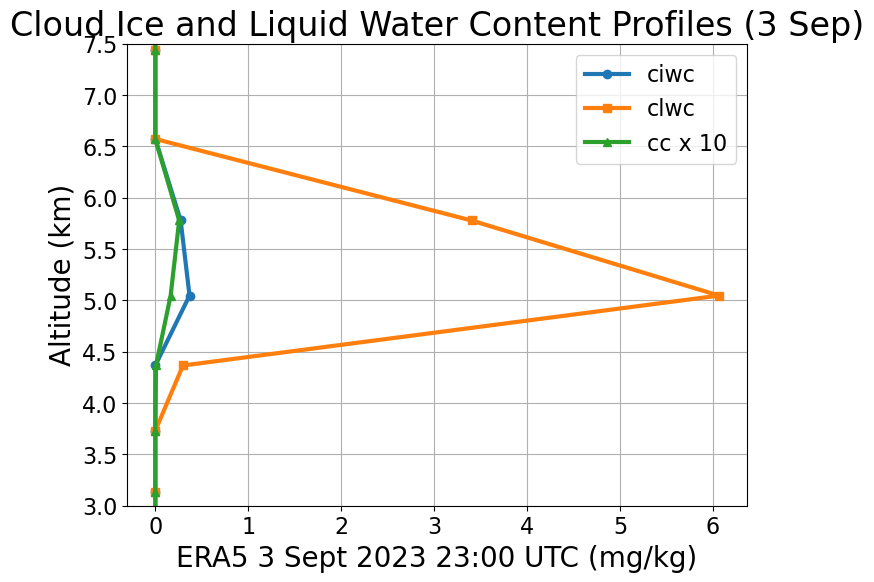

In [20]:
#from those arrays, let's see the ciwc profile, clwc profile, and cloud cover profile as a function of altitude
plt.figure(figsize=(8,6))
plt.plot(ciwc_array*1e6, altitude_array/1000, label='ciwc', marker='o')
plt.plot(clwc_array*1e6, altitude_array/1000, label='clwc', marker='s')
plt.plot(cc_array*10, altitude_array/1000, label='cc x 10', marker='^')
plt.xlabel('ERA5 3 Sept 2023 23:00 UTC (mg/kg)')
plt.ylabel('Altitude (km)')
plt.title('Cloud Ice and Liquid Water Content Profiles (3 Sep)')
plt.ylim(3, 7.5)
plt.legend()
plt.grid()
plt.show()

In [8]:
# 1. Extract the altitude array (in meters)
altitude_profile = atmo_box.super_grid.z
# 2. Extract the calibrated specific humidity profile (in kg/kg) not calibrated
q_interp = atmo_box.super_grid.era5_interp2site(spechfile)
# 3. extratc the temperature profile (in K)
t_interp = atmo_box.super_grid.era5_interp2site(tempfile)
cc_interp = atmo_box.super_grid.era5_interp2site(ccfile)

ciwc_interp = atmo_box.super_grid.era5_interp2site(ciwcfile)
clwc_interp = atmo_box.super_grid.era5_interp2site(clwcfile)

rh_interp = atmo_box.super_grid.era5_interp2site(rhfile)

p_interp = atmo_box.super_grid.pressure # in Pa


# 1. Calculate Virtual Temperature (K)
# Specific humidity affects air density, so we need the virtual temperature first.
t_v_interp = au.virtual_temperature(T=t_interp, q=q_interp)

# 2. Calculate Water Vapor Density (kg / m^3)
rho_wv_interp = au.water_vapor_density(q=q_interp, P=p_interp, T_v=t_v_interp)

# 3. Integrate over the altitude to get PWV
# We use JAX's trapezoidal integration along the altitude axis (z)
pwv_kg_m2 = jnp.trapezoid(rho_wv_interp, x=altitude_profile)

# 4. Convert units
# 1 kg/m^2 of water is exactly equal to 1 mm of precipitable water!
pwv_mm = pwv_kg_m2

print(f"Calculated ERA5 PWV: {pwv_mm:.3f} mm")

Calculated ERA5 PWV: 1.971 mm


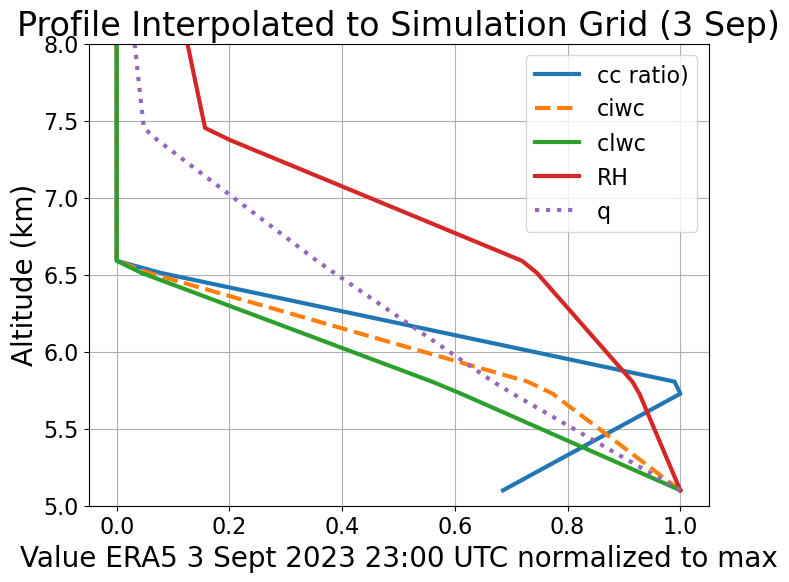

In [5]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp/np.max(cc_interp), altitude_profile/1000, label='cc ratio)')
plt.plot(ciwc_interp*1e3/np.max(ciwc_interp*1e3), altitude_profile/1000, label='ciwc', linestyle='dashed')
plt.plot(clwc_interp*1e3/np.max(clwc_interp*1e3), altitude_profile/1000, label='clwc ')
plt.plot(rh_interp/np.max(rh_interp), altitude_profile/1000, label='RH')
plt.plot(q_interp/np.max(q_interp), altitude_profile/1000, label='q', linestyle='dotted')
plt.xlabel('Value ERA5 3 Sept 2023 23:00 UTC normalized to max')
plt.ylabel('Altitude (km)')
plt.title('Profile Interpolated to Simulation Grid (3 Sep)')
plt.ylim(5, 8)
plt.legend()
plt.grid()
plt.show()

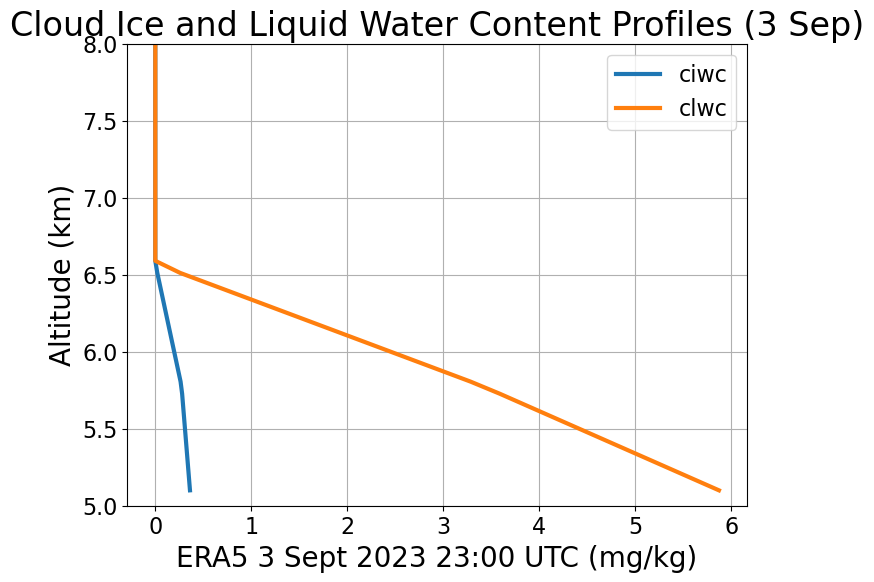

In [6]:
plt.figure(figsize=(8,6))
plt.plot(ciwc_interp*1e6, altitude_profile/1000, label='ciwc')
plt.plot(clwc_interp*1e6, altitude_profile/1000, label='clwc')
plt.xlabel('ERA5 3 Sept 2023 23:00 UTC (mg/kg)')
plt.ylabel('Altitude (km)')
plt.title('Cloud Ice and Liquid Water Content Profiles (3 Sep)')
plt.ylim(5, 8)
plt.legend()
plt.grid()
plt.show()

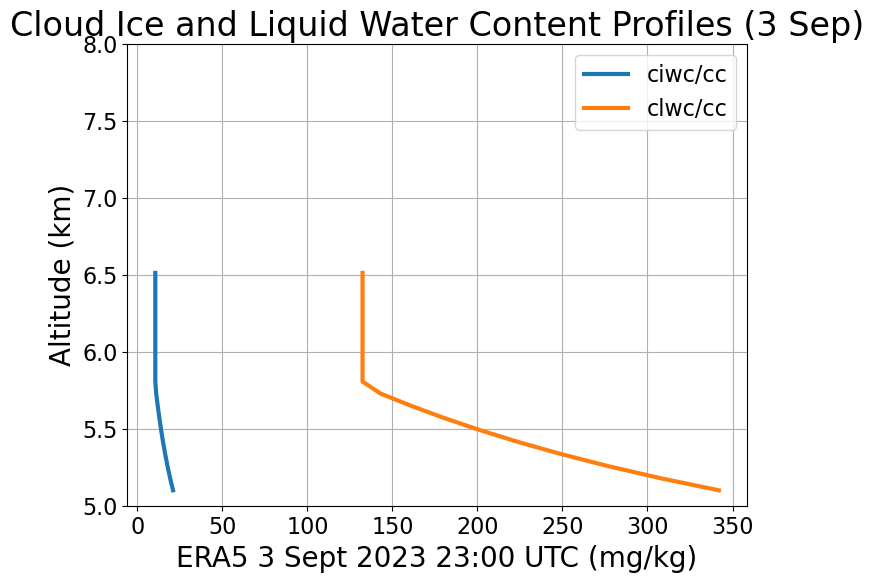

In [9]:
plt.figure(figsize=(8,6))
plt.plot(ciwc_interp*1e6/cc_interp, altitude_profile/1000, label='ciwc/cc')
plt.plot(clwc_interp*1e6/cc_interp, altitude_profile/1000, label='clwc/cc')
plt.xlabel('ERA5 3 Sept 2023 23:00 UTC (mg/kg)')
plt.ylabel('Altitude (km)')
plt.title('Cloud Ice and Liquid Water Content Profiles (3 Sep)')
plt.ylim(5, 8)
plt.legend()
plt.grid()
plt.show()

In [10]:
print("Max CIWC/ max CC ratio:", np.max(ciwc_interp*1e6)/np.max(cc_interp), "mg/kg")
print("Max CLWC/ max CC ratio:", np.max(clwc_interp*1e6)/np.max(cc_interp), "mg/kg")

Max CIWC/ max CC ratio: 14.41874351393506 mg/kg
Max CLWC/ max CC ratio: 234.40655675284924 mg/kg


In [8]:

k_array = np.arange(nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}


In [9]:
seed = 123456789
atmo_box.add_watervapor(power_spec=pspec_q, seed=seed)

atmo_box.generate_realization(time_step=0, component_name='water vapor')

# Extract your final 3D JAX arrays
rho_water_variations_cube = atmo_box.components['water vapor'].field  # in kg/m^3

mean_dict = atmo_box.component_mean['water vapor']

# The dictionary contains 'h' (height/altitude) and 'f' (the mean values)
rho_water_mean_1d = mean_dict['f'] #in kg/m^3

In [10]:
rho_water_total_3d_grid = rho_water_variations_cube + rho_water_mean_1d.reshape(1,1,-1)

#let's calculate the RH

rh_apex_calibration_fluctuations = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_variations_cube, T=t_interp.reshape(1,1,-1)) * 100.0
rh_apex_calibration_total = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_total_3d_grid, T=t_interp.reshape(1,1,-1)) * 100.0

In [11]:

@jax.jit
def cloud_cube_from_cloud_cover_ratio(fluctuations_cube, cc_interp):
    """
    Ultra-optimized JAX implementation using 3D broadcasting.
    Assumes fluctuations_cube is (nx, ny, nz)
    Assumes cc_interp is (nz,)
    """
    nz = fluctuations_cube.shape[2]
    
    # 1. Flatten the spatial dimensions for perfect memory access
    # Transpose to (nz, nx, ny) and flatten to (nz, nx*ny)
    rh_flat = jnp.transpose(fluctuations_cube, (2, 0, 1)).reshape(nz, -1)
    
    # 2. Calculate the target quantiles for all layers (nz,)
    q_targets = jnp.clip(1.0 - cc_interp, 0.0, 1.0)
    
    # 3. vmap ONLY the quantile function (the hardest math operation)
    # This evaluates the exact threshold for all 50+ layers simultaneously
    layer_thresholds = jax.vmap(jnp.quantile)(rh_flat, q_targets)
    
    # 4. Reshape the 1D thresholds to 3D so it broadcasts perfectly
    # Shape becomes (1, 1, nz)
    thresholds_3d = layer_thresholds.reshape(1, 1, nz)
    cc_3d = cc_interp.reshape(1, 1, nz)
    
    # 5. Global 3D Tensor Operation
    # The GPU evaluates the entire cube in one single parallel blast
    cloud_cube = jnp.where(cc_3d > 0.0, fluctuations_cube >= thresholds_3d, 0)
    
    return cloud_cube.astype(jnp.int32)

In [13]:
#let's calculate the cloud cube with RH fluctuations
cloud_cube_rh_fluctuations = cloud_cube_from_cloud_cover_ratio(rh_apex_calibration_fluctuations, cc_interp)

#Let's calculate the cloud cube from rho_water fluctuations
cloud_cube_rho_water_fluctuations = cloud_cube_from_cloud_cover_ratio(rho_water_variations_cube, cc_interp)

In [15]:
#Let's  see if the cloud cubes are the same by comparing them (we do the difference and check if it's all zeros)
difference_cube = cloud_cube_rh_fluctuations - cloud_cube_rho_water_fluctuations
all_zeros = jnp.all(difference_cube == 0)
print(f"Are the cloud cubes identical? {all_zeros}")

Are the cloud cubes identical? True


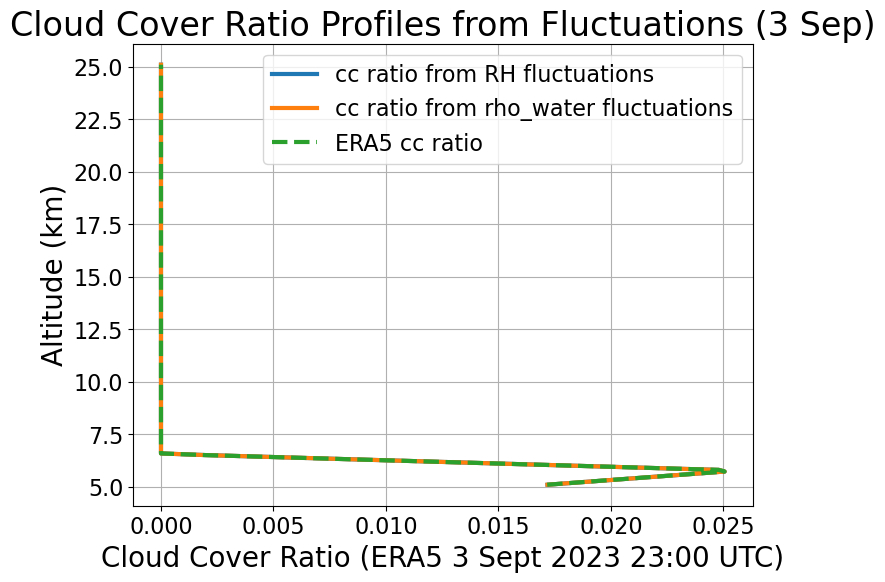

In [14]:
cc_ratio_atmo3_rh = jnp.mean(cloud_cube_rh_fluctuations, axis=(0,1))

cc_ratio_atmo3_rho_water = jnp.mean(cloud_cube_rho_water_fluctuations, axis=(0,1))

plt.figure(figsize=(8,6))
plt.plot(cc_ratio_atmo3_rh, altitude_profile/1000, label='cc ratio from RH fluctuations')
plt.plot(cc_ratio_atmo3_rho_water, altitude_profile/1000, label='cc ratio from rho_water fluctuations')
plt.plot(cc_interp, altitude_profile/1000, label='ERA5 cc ratio', linestyle='dashed')
plt.xlabel('Cloud Cover Ratio (ERA5 3 Sept 2023 23:00 UTC)')
plt.ylabel('Altitude (km)')
plt.title('Cloud Cover Ratio Profiles from Fluctuations (3 Sep)')
plt.legend()
plt.grid()
plt.show()

In [16]:
atmo_box.add_temperature(power_spec=pspec_ta, seed=seed)

atmo_box.generate_realization(time_step=0, component_name='temperature')

# Extract your final 3D JAX arrays
Temperature_variations_cube = atmo_box.components['temperature'].field  # in kg/m^3

mean_dict = atmo_box.component_mean['temperature']

# The dictionary contains 'h' (height/altitude) and 'f' (the mean values)
T_mean_1d = mean_dict['f'] #in kg/m^3


In [19]:
Temperature_total_cube = Temperature_variations_cube + T_mean_1d.reshape(1,1,-1)
#Let's calculate the RH fluctuations from both the temperature and the water vapor fluctuations together to see if we get the same cloud cube as before
rh_from_both_fluctuations = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_variations_cube, T=Temperature_total_cube) * 100.0


In [20]:
cloud_cube_both_fluctuations = cloud_cube_from_cloud_cover_ratio(rh_from_both_fluctuations, cc_interp)

In [21]:
difference_cube_both = cloud_cube_rh_fluctuations - cloud_cube_both_fluctuations
all_zeros_both = jnp.all(difference_cube_both == 0)
print(f"Are the cloud cubes from RH fluctuations and both fluctuations identical? {all_zeros_both}")

Are the cloud cubes from RH fluctuations and both fluctuations identical? False


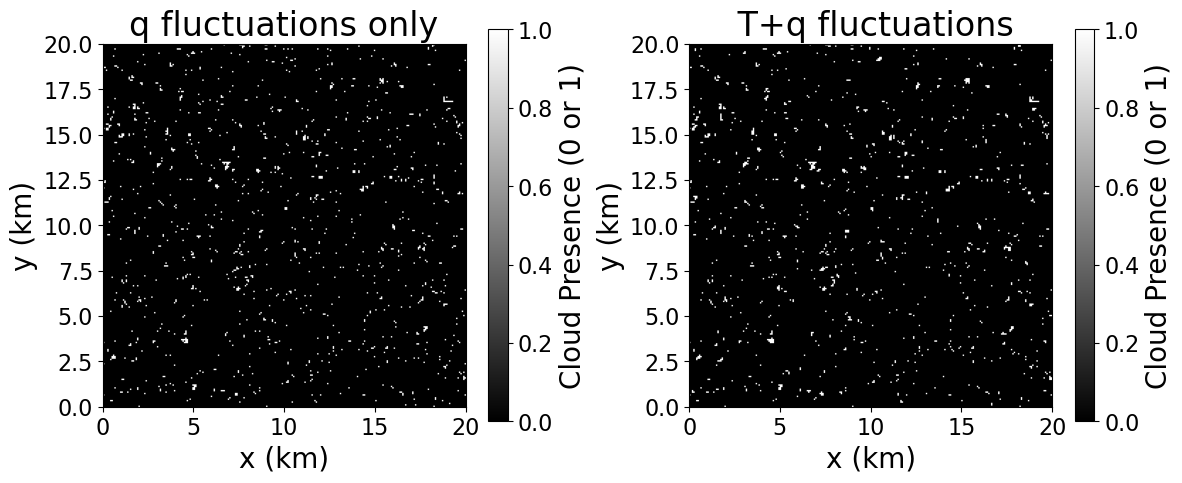

In [25]:
#Let's plot a slice of the cloud cube in x-y plane to see the differences by taking into account the fluctuations in both temperature and water vapor together and only the fluctuations in water vapor (RH) to see if there are any differences in the cloud cube. We will take a slice at a specific altitude level, say at 6 km, which corresponds to a certain index in the vertical dimension of the cube. We will then visualize this slice as an image to compare the two cloud cubes.

altitude_level_km = 6.0
altitude_level_m = altitude_level_km * 1000.0
# Find the index in the altitude array that is closest to 6 km
altitude_index = jnp.argmin(jnp.abs(altitude_profile - altitude_level_m))
cloud_slice_rh = cloud_cube_rh_fluctuations[:,:,altitude_index]
cloud_slice_both = cloud_cube_both_fluctuations[:,:,altitude_index]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cloud_slice_rh, origin='lower', cmap='gray',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'q fluctuations only')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.colorbar(label='Cloud Presence (0 or 1)')
plt.subplot(1,2,2)
plt.imshow(cloud_slice_both, origin='lower', cmap='gray',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f' T+q fluctuations')
plt.colorbar(label='Cloud Presence (0 or 1)')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.tight_layout()
plt.show()

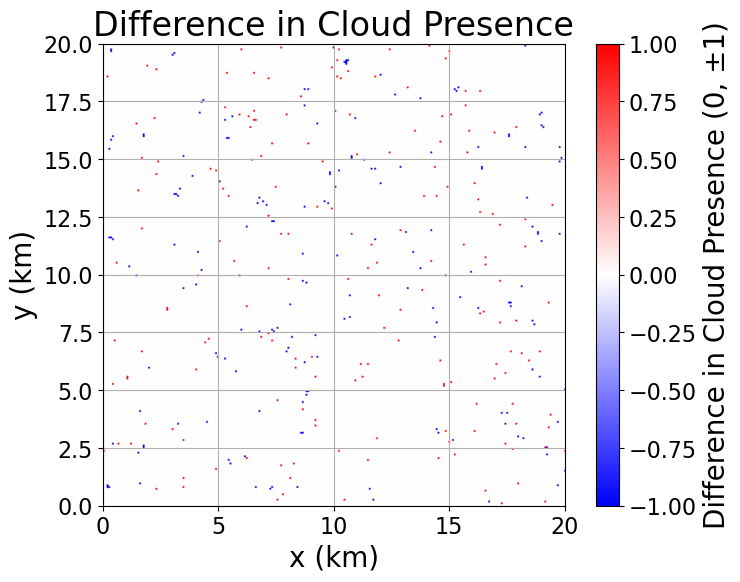

In [27]:
#Let's plot the difference between the two maps

difference_slice = cloud_slice_rh - cloud_slice_both
plt.figure(figsize=(8,6))
plt.imshow(difference_slice, origin='lower', cmap='bwr',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title('Difference in Cloud Presence')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.colorbar(label='Difference in Cloud Presence (0, ±1)')
plt.grid()
plt.show()

In [1]:
# %%
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 3,
})

# %%
# =============================================================================
# 2. Simulation Parameters & Paths
# =============================================================================
q_injection_scale_in_m  = 500.0  
ta_injection_scale_in_m = 200.0  
nside_grid = [256, 256, 256]
box_length = [20000., 20000., 20000.]
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  
time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
apexfile   = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'



2.526086956521739 0.07649950269801416
Cloud cube generated with shape: (256, 256, 256)


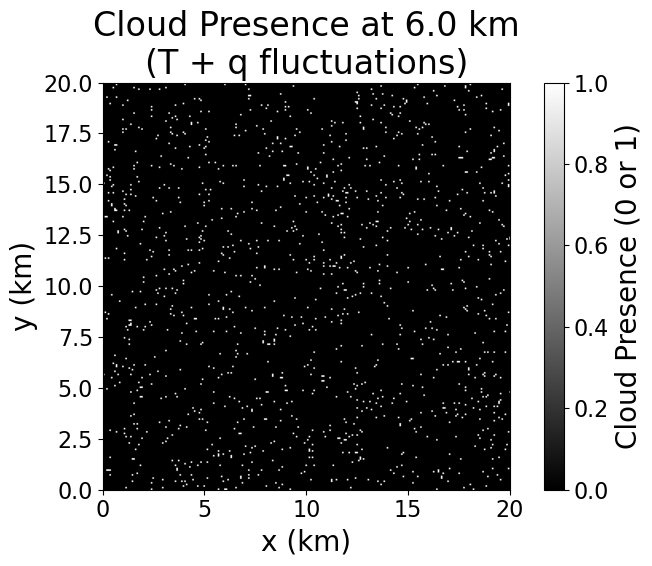

In [2]:
# =============================================================================
# 3. Initialize Atmosphere and Power Spectra
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

# Calculate power spectra
k_array = np.arange(nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)
k0_q  = 2*np.pi / q_injection_scale_in_m   
k0_ta = 2*np.pi / ta_injection_scale_in_m  

pofk_q  = (k0_q**2.  + k_array**2)**-(11/6)
pofk_ta = (k0_ta**2. + k_array**2)**-(11/6)
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}

# %%
# =============================================================================
# 4. Generate Primary Fields (Temperature & Water Vapor)
# =============================================================================
seed = 123456789

# Add components
atmo_box.add_watervapor(power_spec=pspec_q, seed=seed)
atmo_box.add_temperature(power_spec=pspec_ta, seed=seed)

# Generate 3D realizations (fluctuations + calibration)
atmo_box.generate_realization(time_step=0)

# %%
# =============================================================================
# 5. Derive the Cloud Mask
# =============================================================================
# This single call replaces all the manual RH calculation and quantile thresholding
cloud_cube = atmo_box.derive_cloud_mask(ccfile)

print(f"Cloud cube generated with shape: {cloud_cube.shape}")

# %%
# =============================================================================
# 6. Plotting the Results
# =============================================================================
altitude_profile = atmo_box.super_grid.z
altitude_level_km = 6.0
altitude_level_m = altitude_level_km * 1000.0

# Find the index in the altitude array that is closest to 6 km
altitude_index = jnp.argmin(jnp.abs(altitude_profile - altitude_level_m))

# Extract the 2D slice from the newly generated cloud mask
cloud_slice = cloud_cube[:, :, altitude_index]

plt.figure(figsize=(8,6))
plt.imshow(cloud_slice, origin='lower', cmap='gray',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'Cloud Presence at {altitude_level_km} km\n(T + q fluctuations)')
plt.colorbar(label='Cloud Presence (0 or 1)')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.tight_layout()
plt.show()